# Section 1 — CLO ETFs: the democratization dataset

Thin driver notebook: all logic lives in `src/etf/`. This notebook only imports, orchestrates (scrape -> analysis -> viz), and displays. Run `make etf` from the repo root to do the same thing headlessly.

Scraping hits live network endpoints (Janus Henderson full-holdings pages, Yahoo Finance via `yfinance`, FRED). Re-running is safe: `CachedSession` skips URLs already in `data/raw/_manifest.csv`, and `scrape_holdings.py` / `scrape_nav_flows.py` are idempotent.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

from IPython.display import Image, display

from src.etf import (
    scrape_holdings, scrape_nav_flows,
    analysis_flows, analysis_nav_dislocation, analysis_tranche_panel, analysis_manager_league, analysis_returns,
    viz_growth, viz_dislocation, viz_tranche, viz_league, viz_returns,
)

/Users/zinuoshi/clo-atlas/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Scrape (raw -> interim)
Set `RUN_SCRAPE = True` to hit the network; otherwise this notebook runs entirely from whatever is already cached in `data/interim/`.

In [2]:
RUN_SCRAPE = False
if RUN_SCRAPE:
    scrape_holdings.run()
    scrape_nav_flows.run()

## Analysis (interim -> final)

In [3]:
flows = analysis_flows.run()
dislocation = analysis_nav_dislocation.run()
tranche = analysis_tranche_panel.run()
league = analysis_manager_league.run()
returns = analysis_returns.run()

NAV snapshot history has only 1 distinct date(s); need >=2 to compute flows. Run scrape_nav_flows.py again on a later day.


flows_monthly is empty; flow_event_study returns an empty frame rather than interpolating


8 fund(s) have <30 days of NAV history; distribution stats are provisional: ['CLOA', 'CLOB', 'CLOD', 'CLOI', 'CLOZ', 'ICLO', 'JAAA', 'JBBB']


dropping 25/843 holdings rows as non-tranche line items or implausible marks (bad CUSIP format or price outside (80.0, 112.0))


holdings history has <2 distinct dates; deal_movers needs at least two scrape_holdings.py runs


holdings history has <2 distinct dates; tranche_turnover needs at least two scrape_holdings.py runs


## Viz (final -> figures/)

flows_monthly is empty (need >=2 NAV snapshot dates); skipping viz_monthly_flows for now


dropping 25/843 holdings rows as non-tranche line items or implausible marks (bad CUSIP format or price outside (80.0, 112.0))


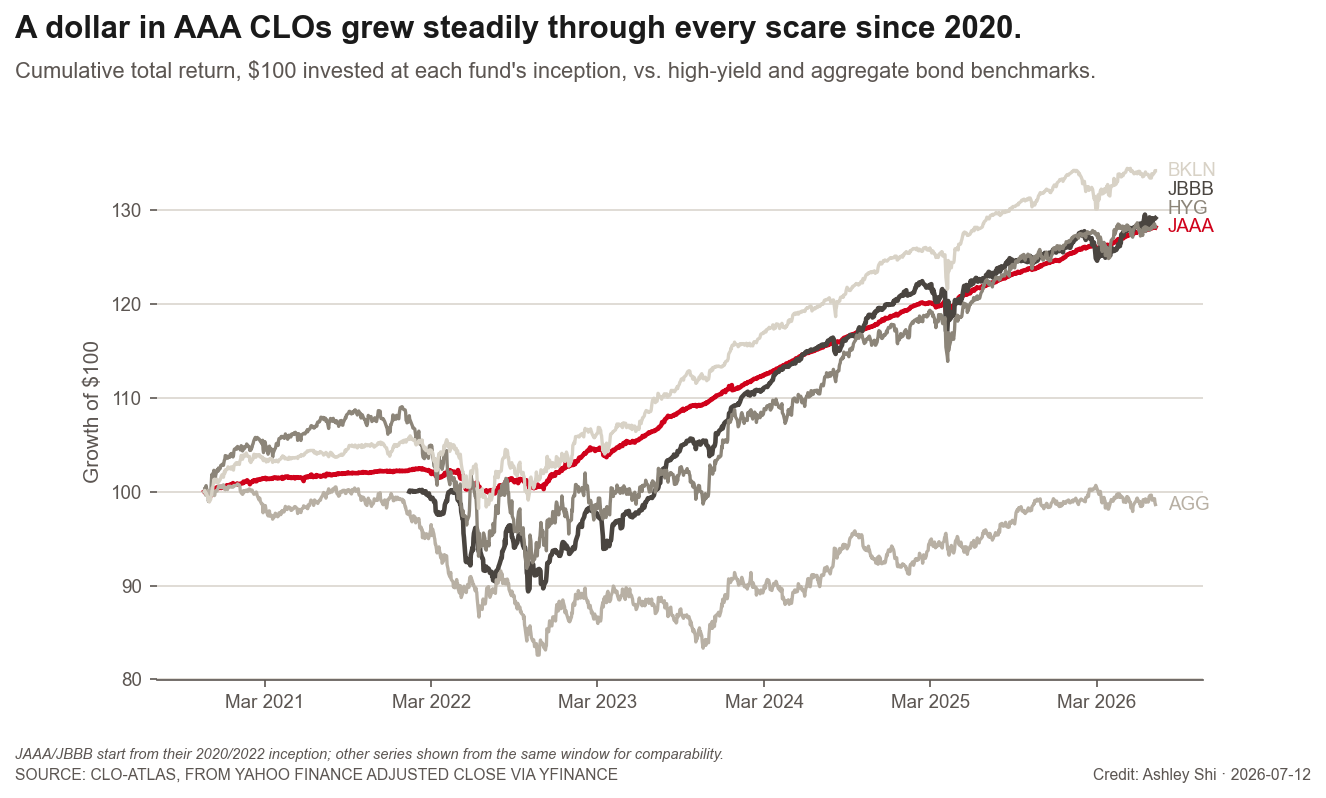

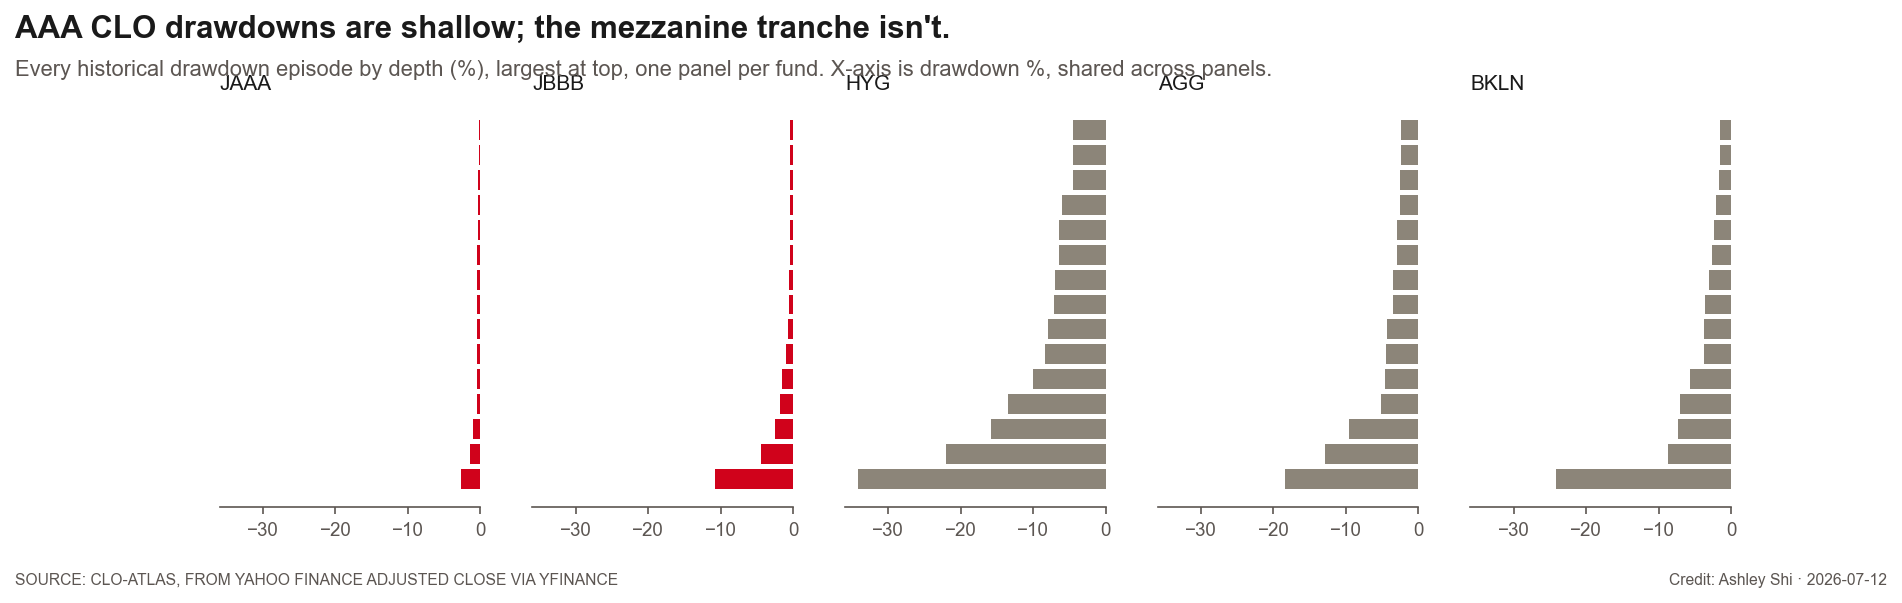

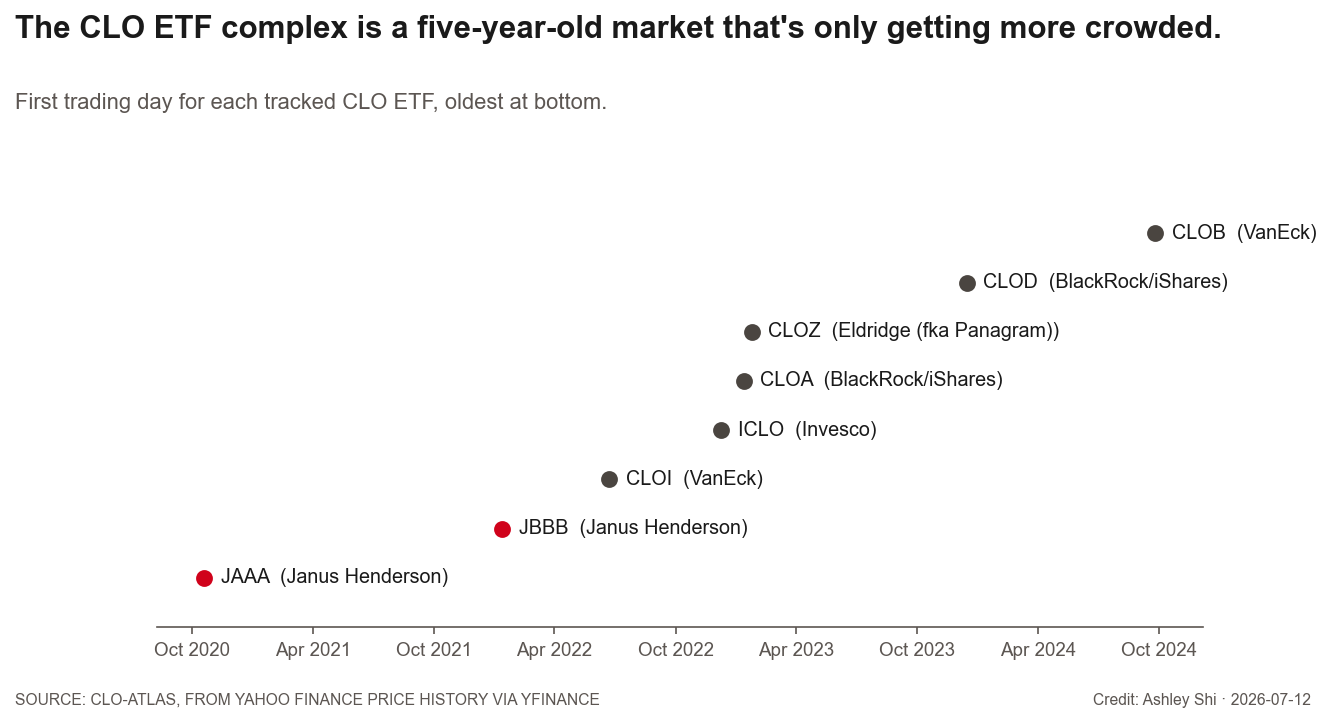

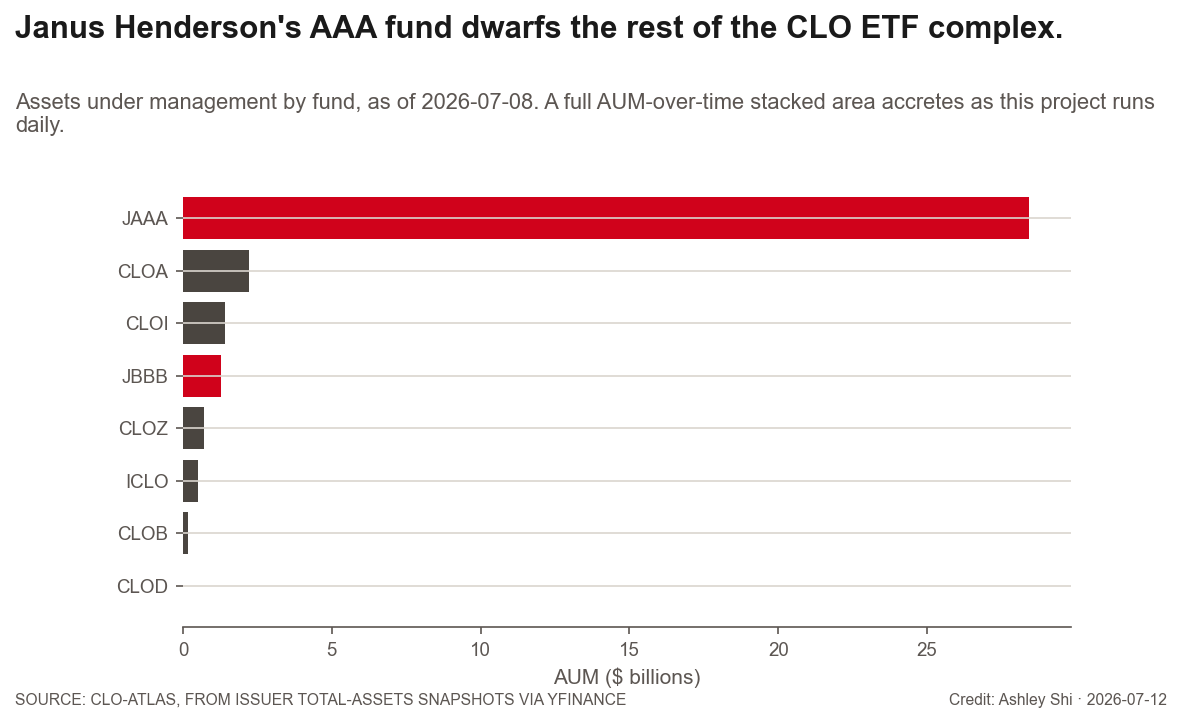

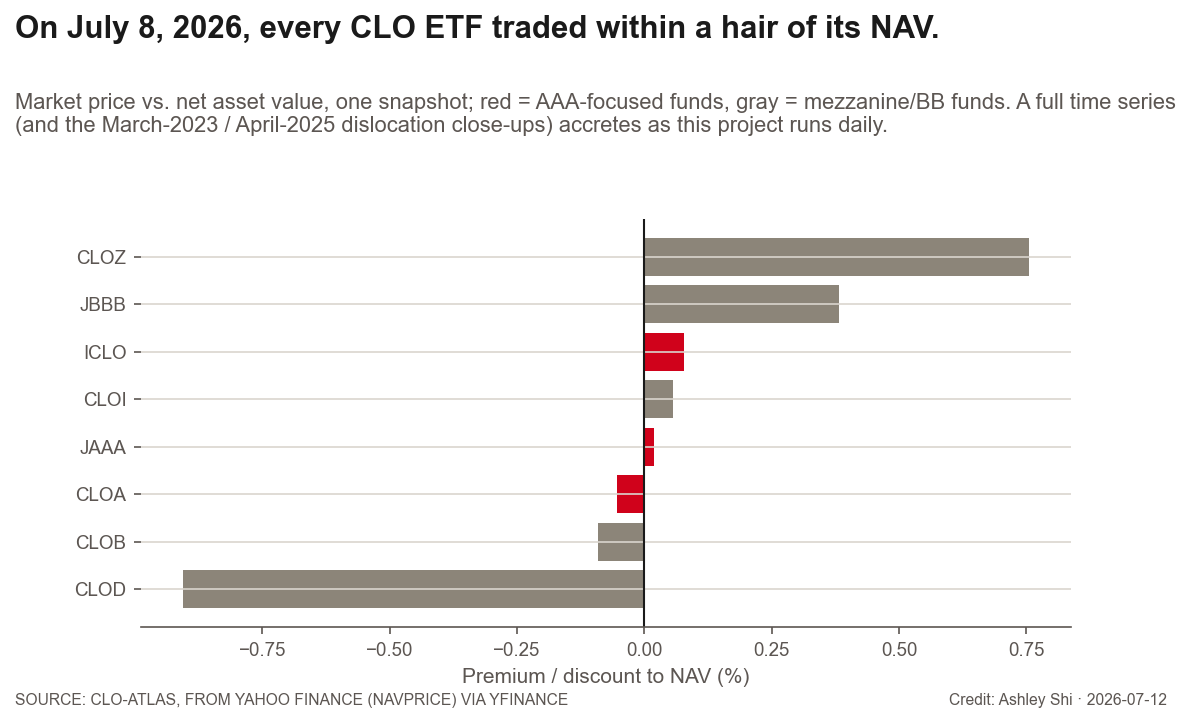

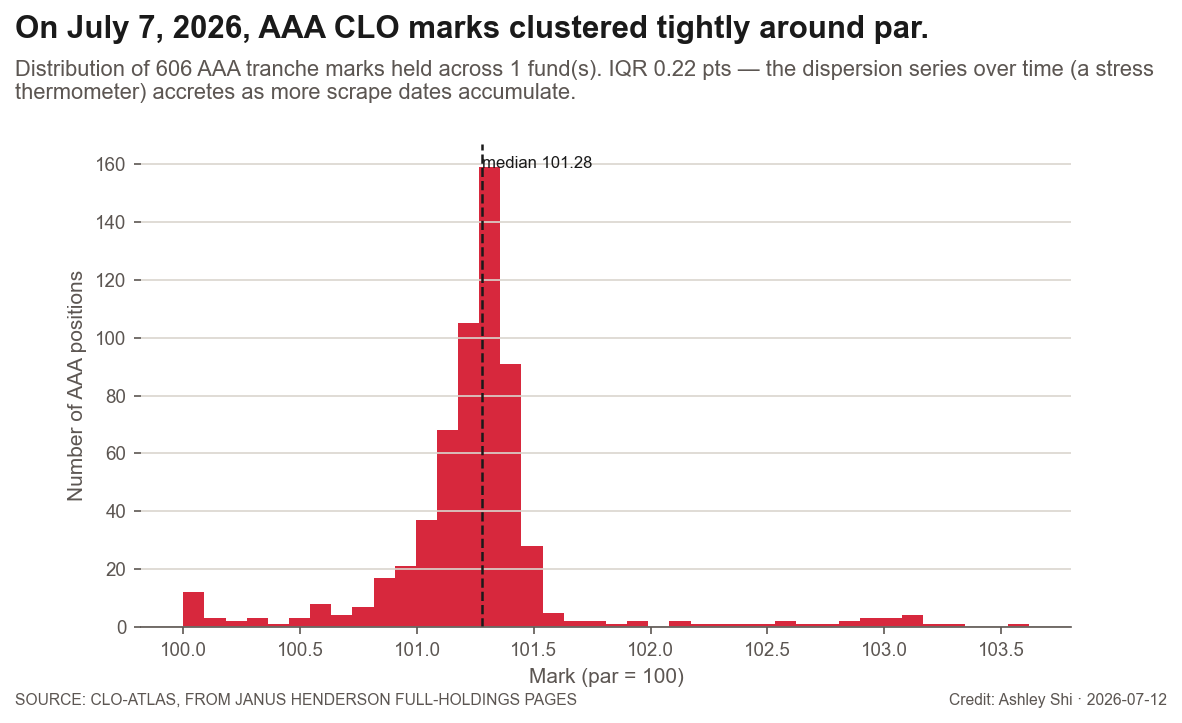

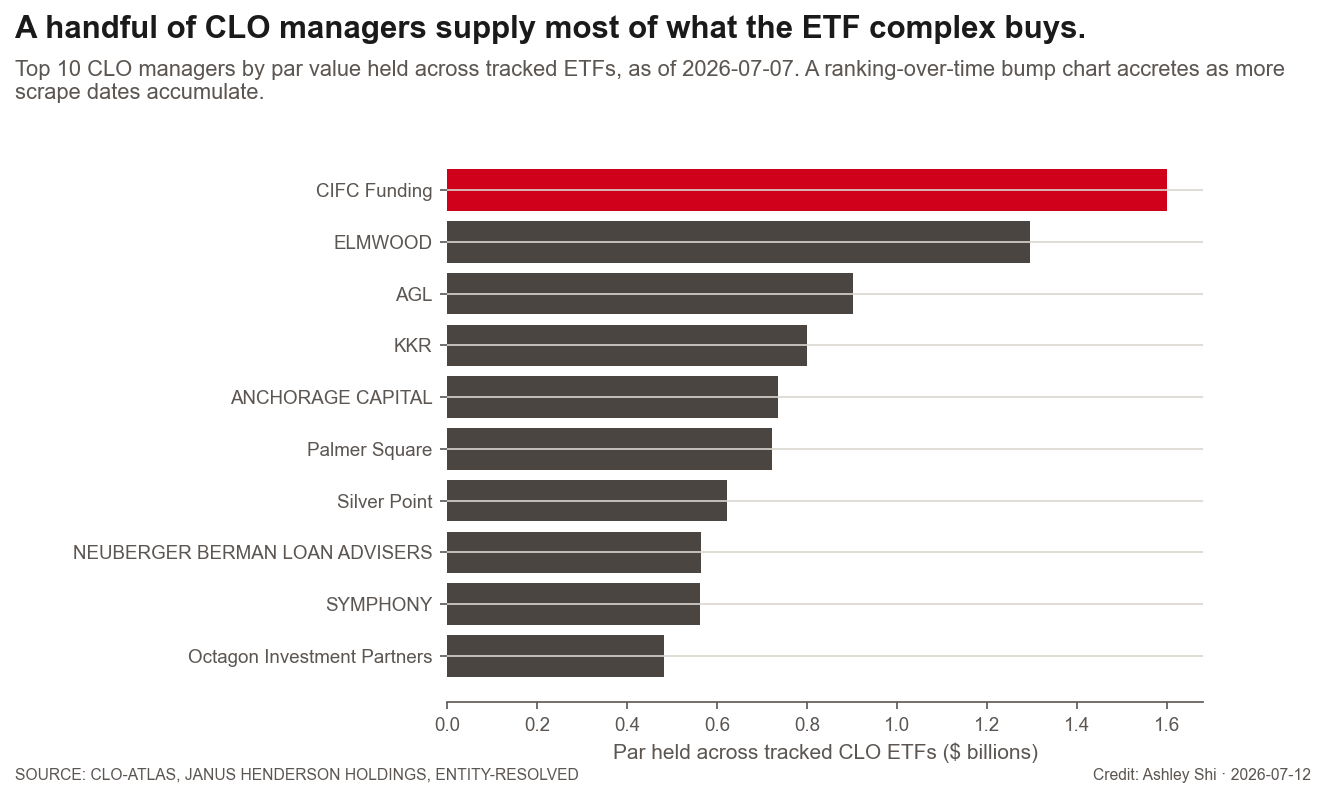

In [4]:
viz_returns.run()
viz_growth.run()
viz_dislocation.run()
viz_tranche.run()
viz_league.run()

## Exhibits

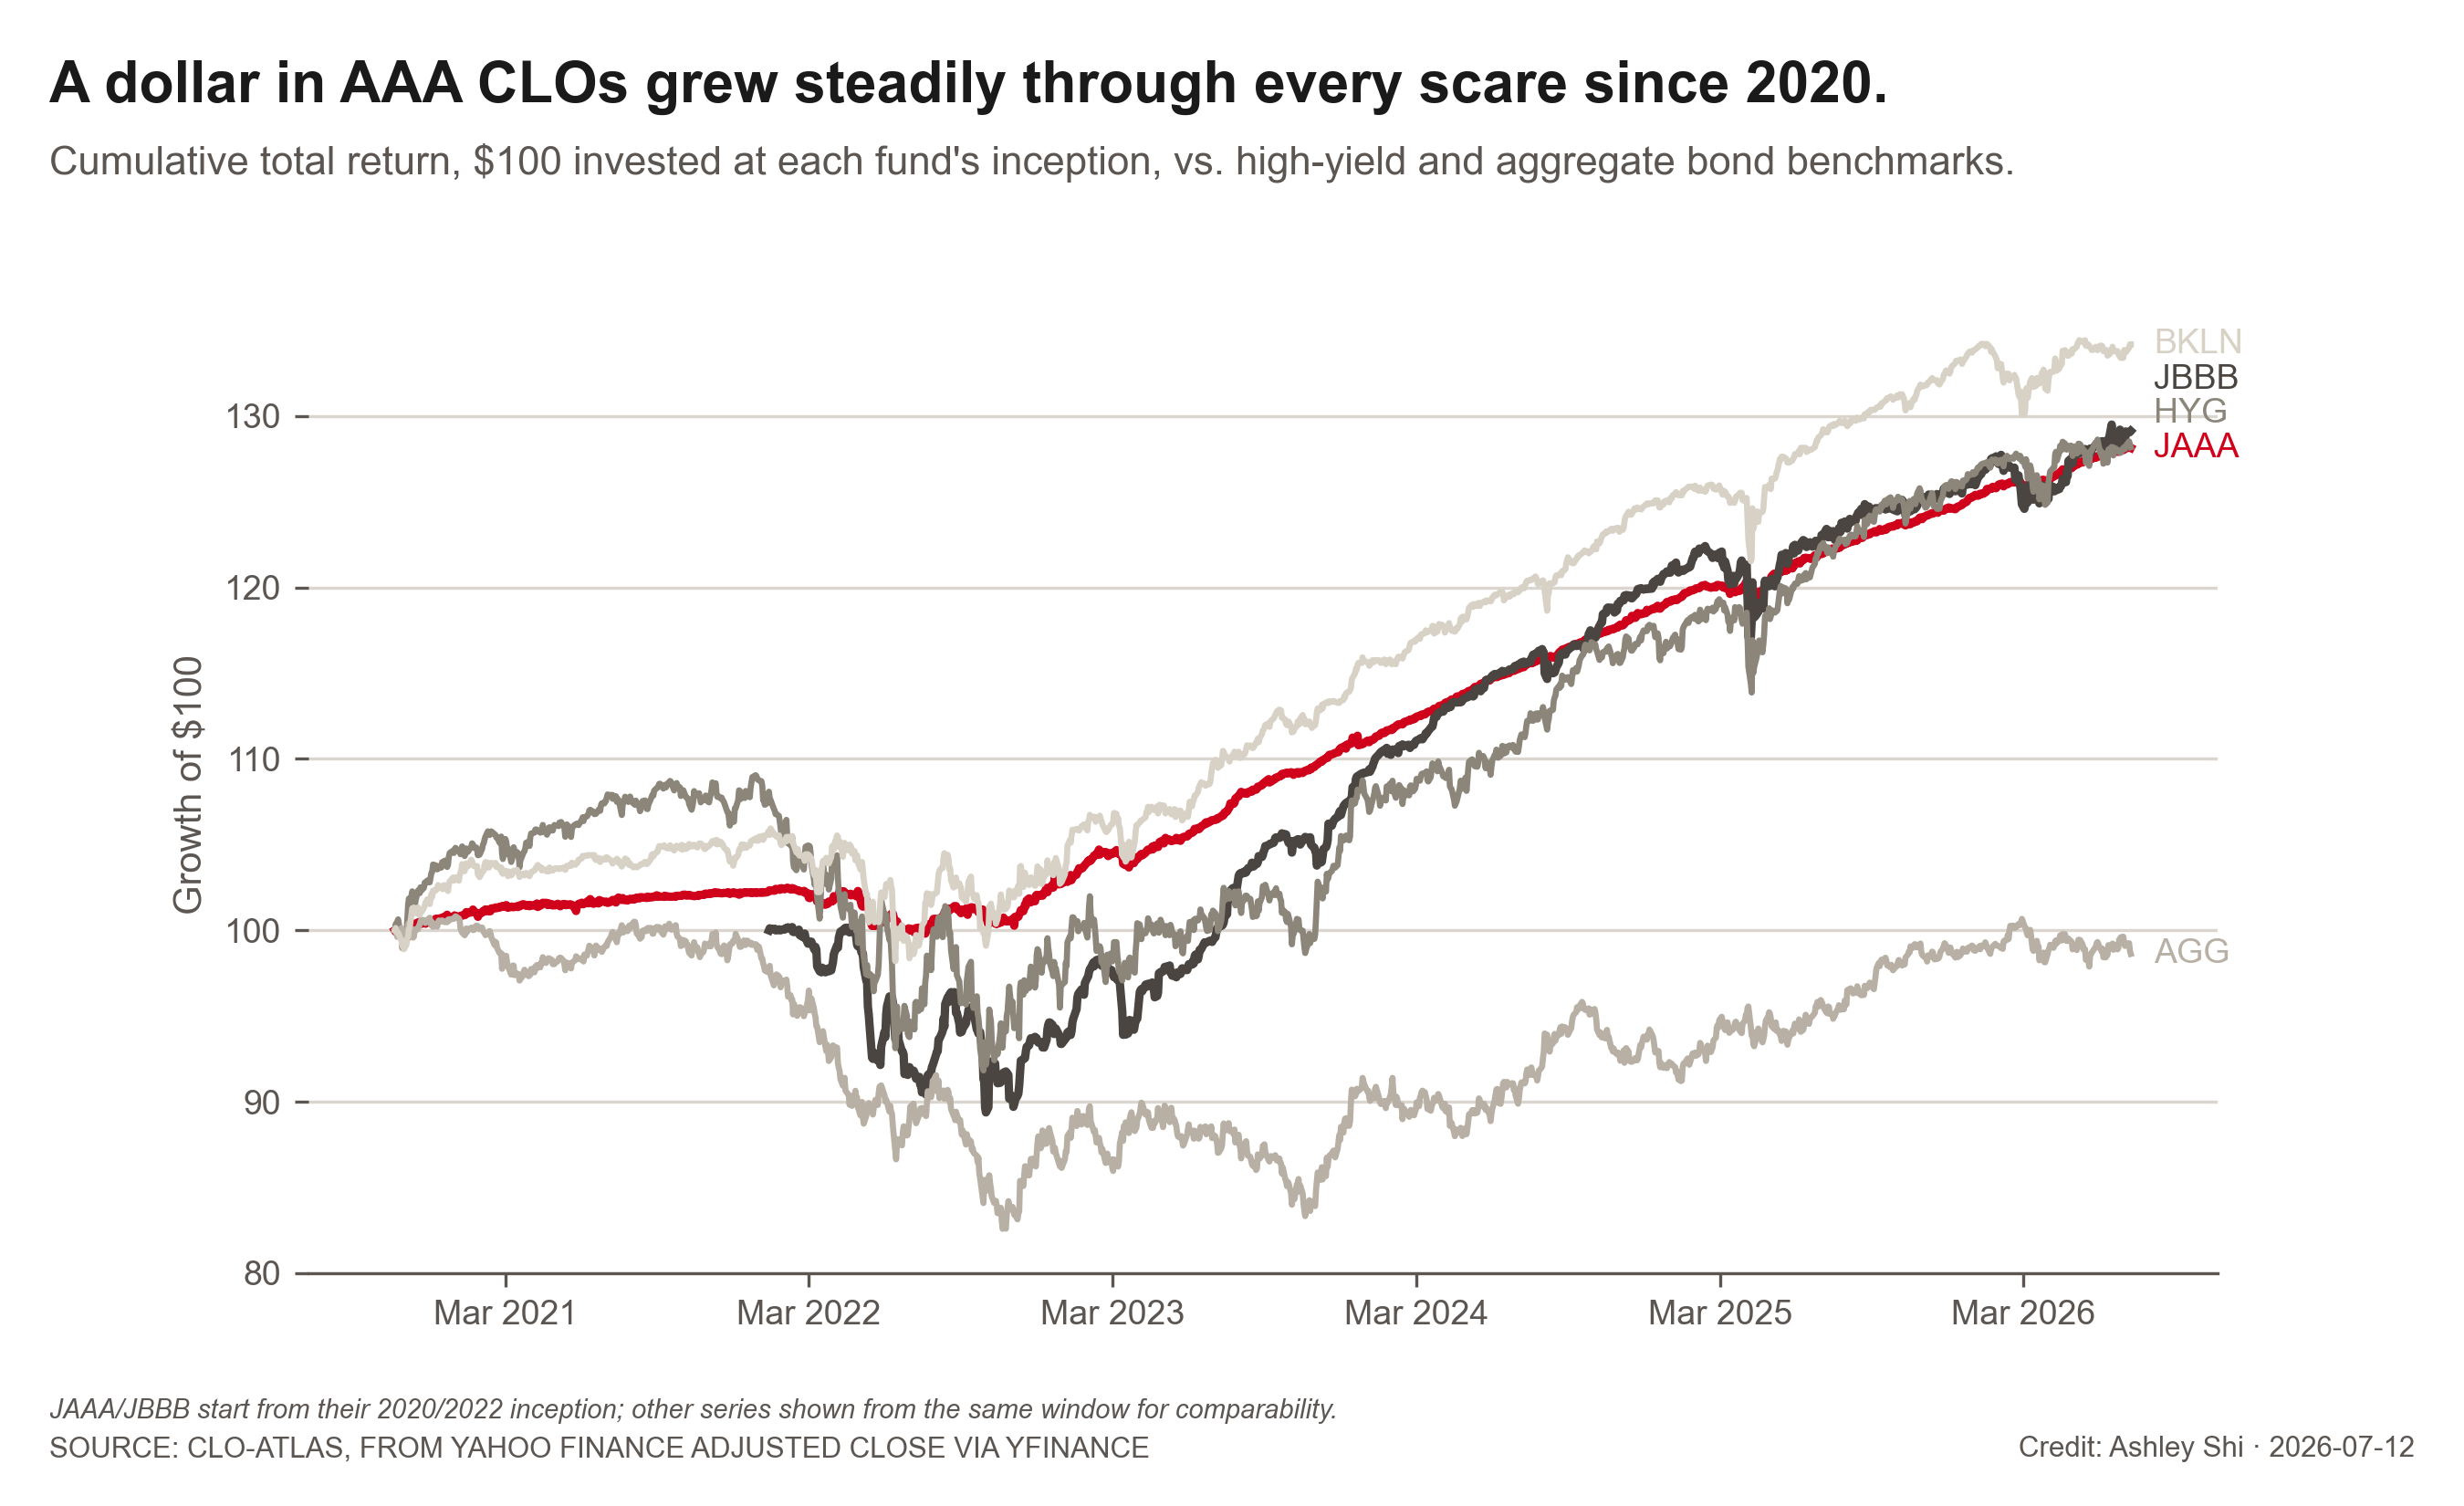

In [5]:
path = pathlib.Path("../figures") / "viz_growth_of_100.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print("[skipped — not generated this run] viz_growth_of_100")

**VERIFIED**, computed here: source is Yahoo Finance daily adjusted-close price history pulled via `yfinance` (`src/etf/scrape_nav_flows.py`), compounded into a growth-of-$100 series by `src/etf/analysis_returns.py:growth_of_100` (docs/sources.md, Section 1, "Yahoo Finance (via yfinance)" row). The chart rebases $100 to JAAA's October 19, 2020 inception and tracks it through JAAA, JBBB, and three non-CLO comparison tickers (HYG, AGG, BKLN) from that same start date, so every line covers identical calendar days. By July 2026, JAAA compounded to about $128 and JBBB to about $129 — both roughly in line with HYG ($128) and well ahead of the aggregate-bond benchmark AGG ($99) — across a window spanning the 2022 hiking cycle, the March 2023 regional-bank stress, and this year's tariff shock. For the "democratization" framing this is the headline exhibit: CLO tranche exposure, bought through an ordinary brokerage ticker, produced returns competitive with high-yield credit without requiring direct participation in the CLO deal market.

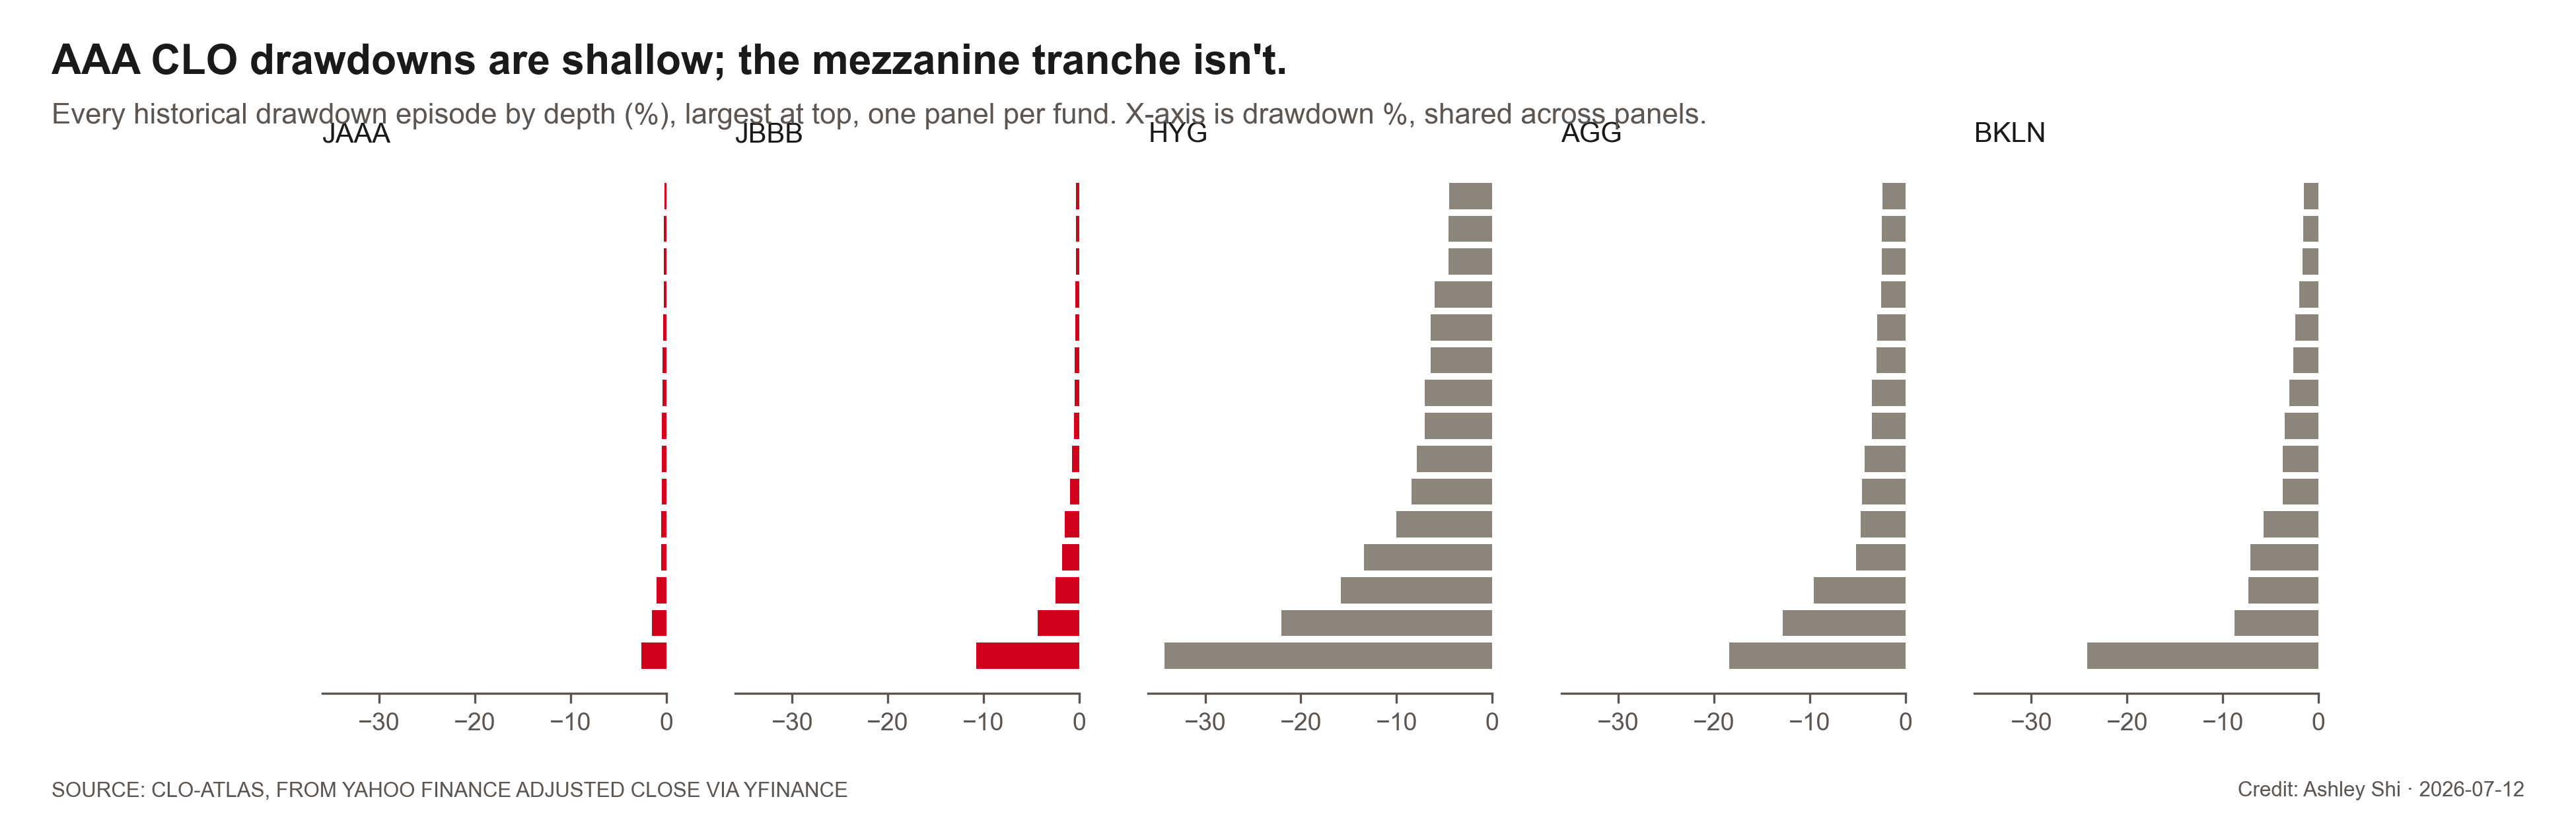

In [6]:
path = pathlib.Path("../figures") / "viz_drawdown_small_multiples.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print("[skipped — not generated this run] viz_drawdown_small_multiples")

**VERIFIED**, computed here: same source and pipeline as the growth chart — Yahoo Finance adjusted-close history via `yfinance` — this time run through `src/etf/analysis_returns.py:drawdown_duration_profile`, which walks each ticker's full price history and records every peak-to-trough drawdown episode's depth and recovery time. Each panel is one ticker's 15 deepest episodes on a shared drawdown-% x-axis; unlike the growth-of-$100 chart this one is *not* clipped to a common start date, so HYG/AGG/BKLN's episodes reach back to their real, earlier inceptions while JAAA/JBBB only go back to 2020/2022. **VERIFIED**: JAAA's worst drawdown in its entire trading history is -2.6% (Feb 2022) and JBBB's is -10.8% (also Feb 2022), versus -34.2% for HYG (Sep 2007) and -18.4% for AGG (Aug 2020) — the tranche-selection story in one picture: AAA CLO risk barely moves across a full market cycle, while mezzanine CLO and generic high-yield credit both take real, multi-year hits.

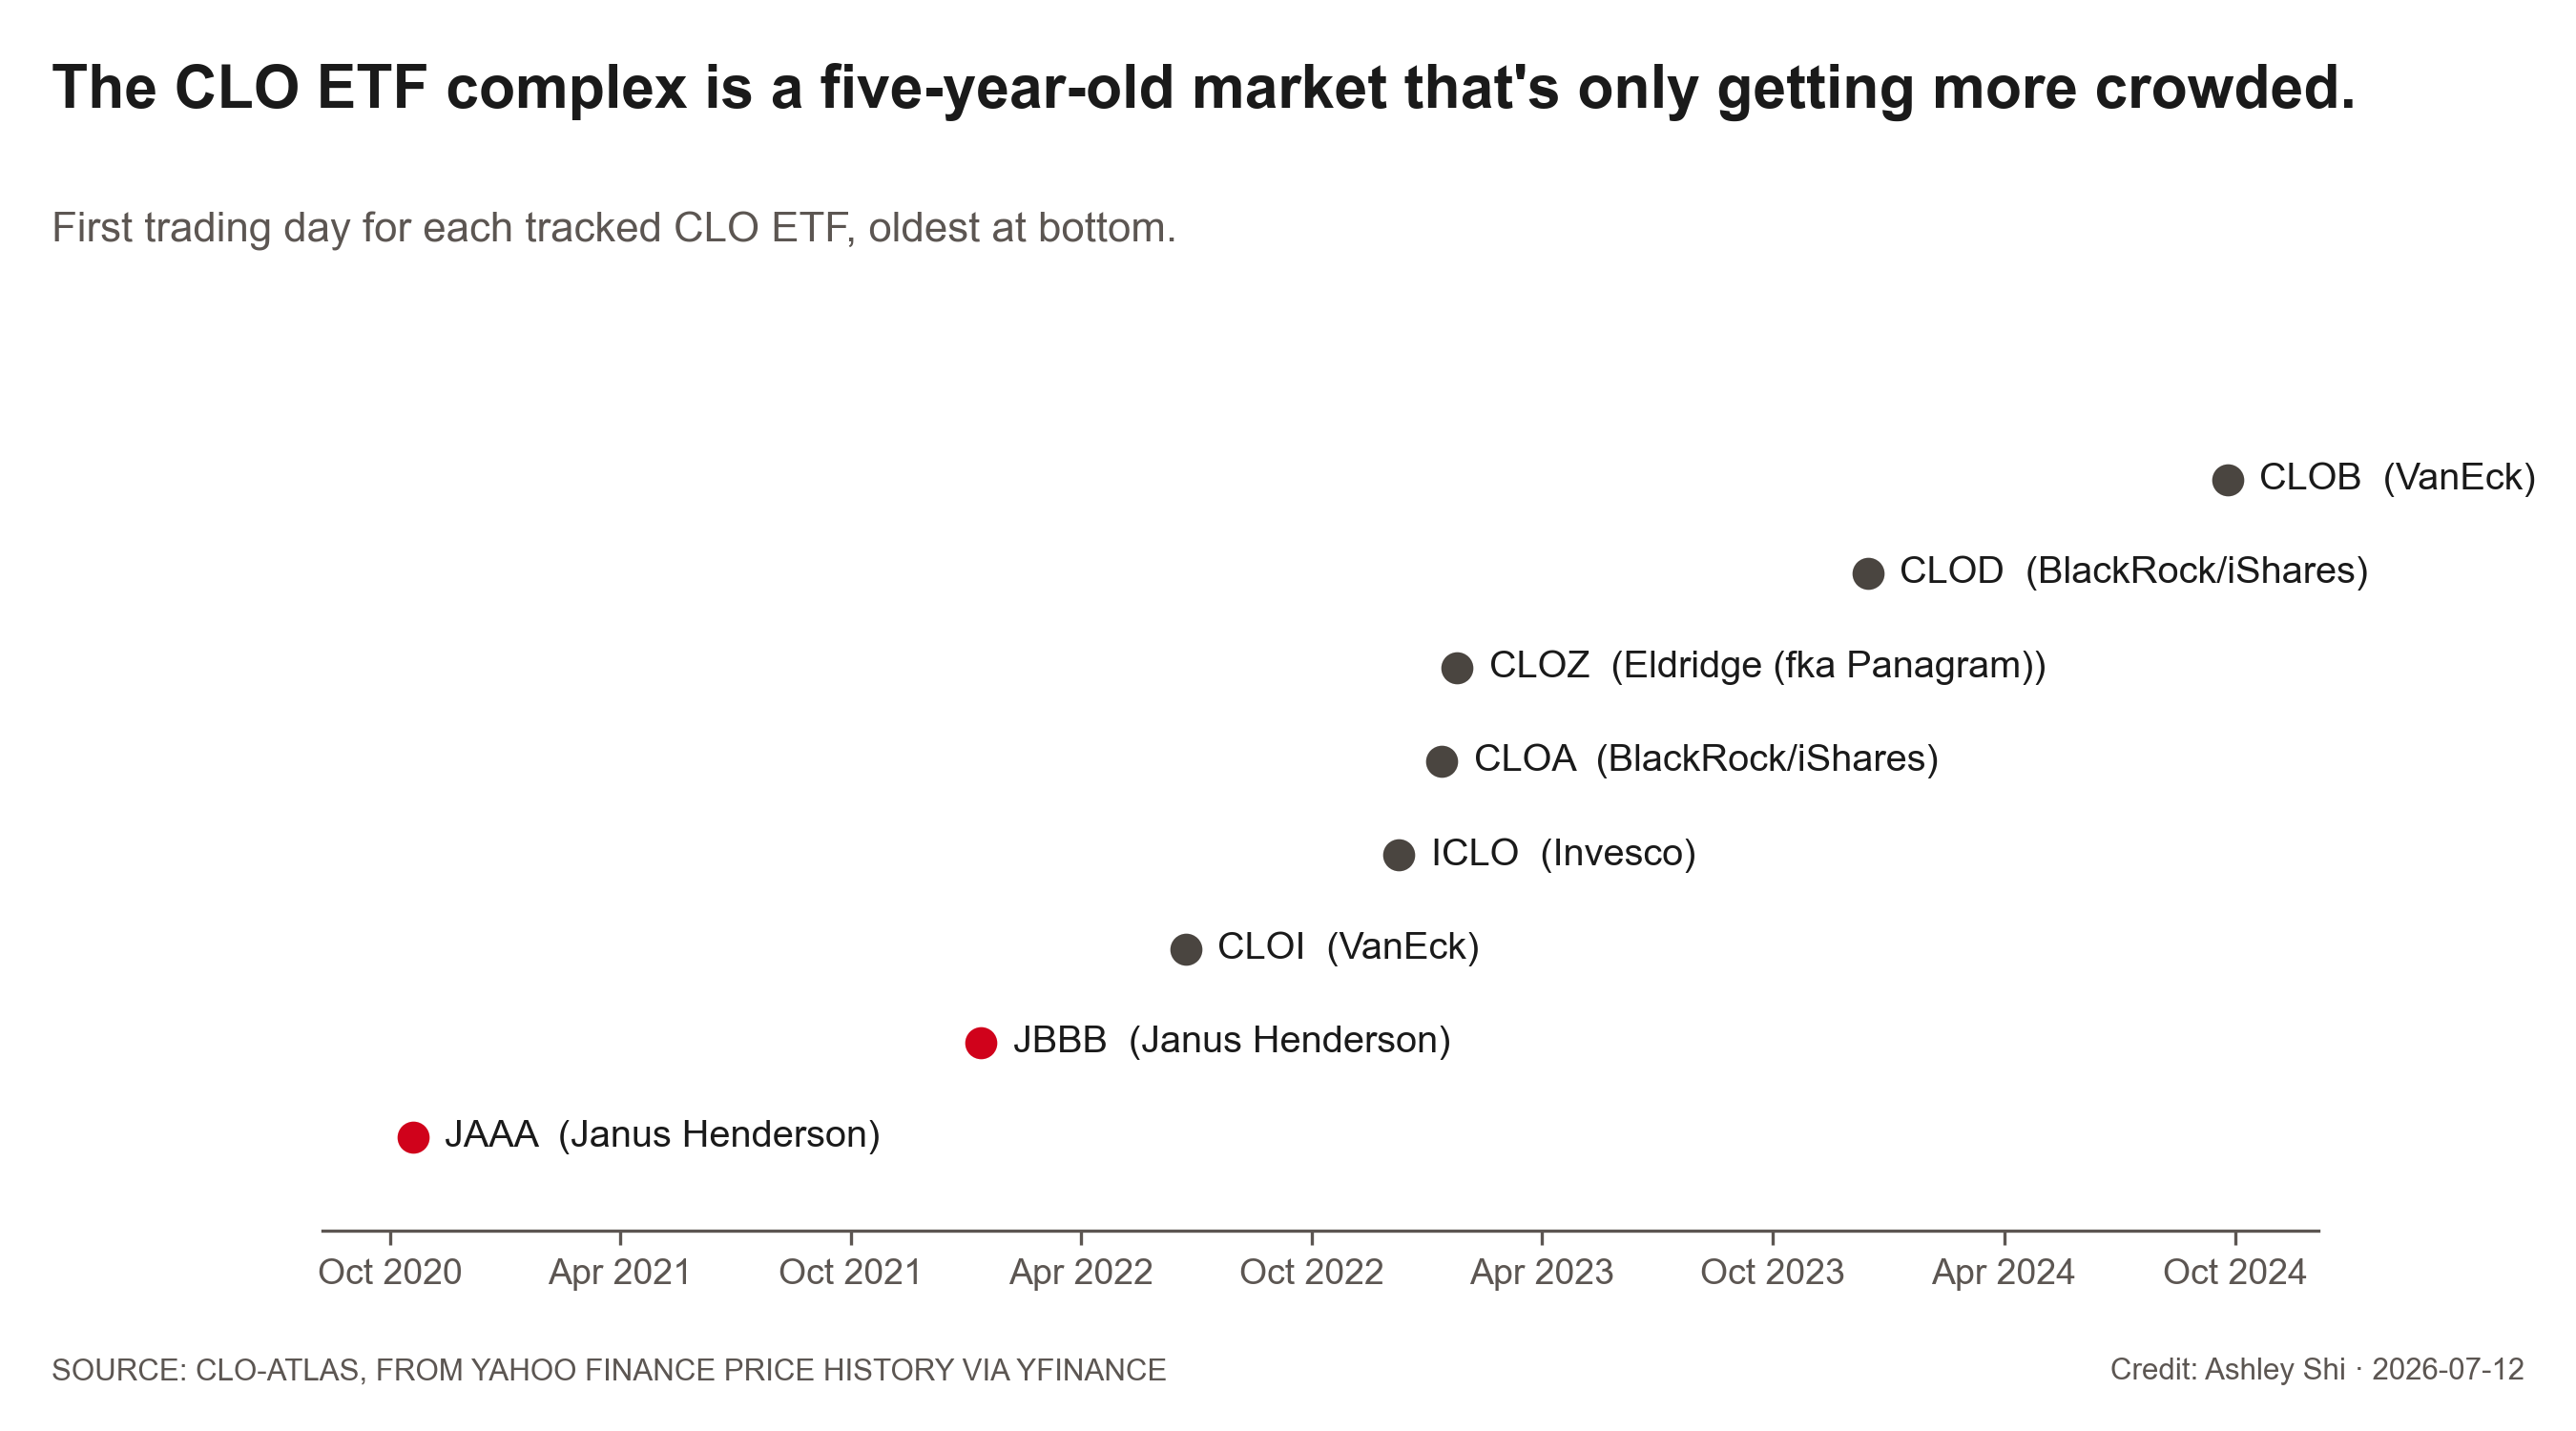

In [7]:
path = pathlib.Path("../figures") / "viz_launch_timeline.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print("[skipped — not generated this run] viz_launch_timeline")

**VERIFIED**, computed here: launch dates are each ticker's earliest trading day in the Yahoo Finance OHLCV history pulled via `yfinance` (`src/etf/scrape_nav_flows.py`), read off directly by `src/etf/analysis_flows.py:launch_timeline` rather than quoted from an issuer press release. The chart plots all 8 tracked CLO ETFs on a single date axis, oldest at the bottom: JAAA (Janus Henderson, AAA, Oct 2020) leads, JBBB follows in Jan 2022, then CLOI/ICLO/CLOA/CLOZ cluster in 2022-23, with CLOD and CLOB only arriving in late 2023 and 2024. Against the democratization thesis, this is the timeline of when CLO exposure actually became a listed, retail-buyable product: five different issuers now compete for the same trade, and the accelerating launch cadence into 2023-2024 signals the market treating CLO-tranche ETFs as a real, replicable product category rather than one issuer's one-off experiment.

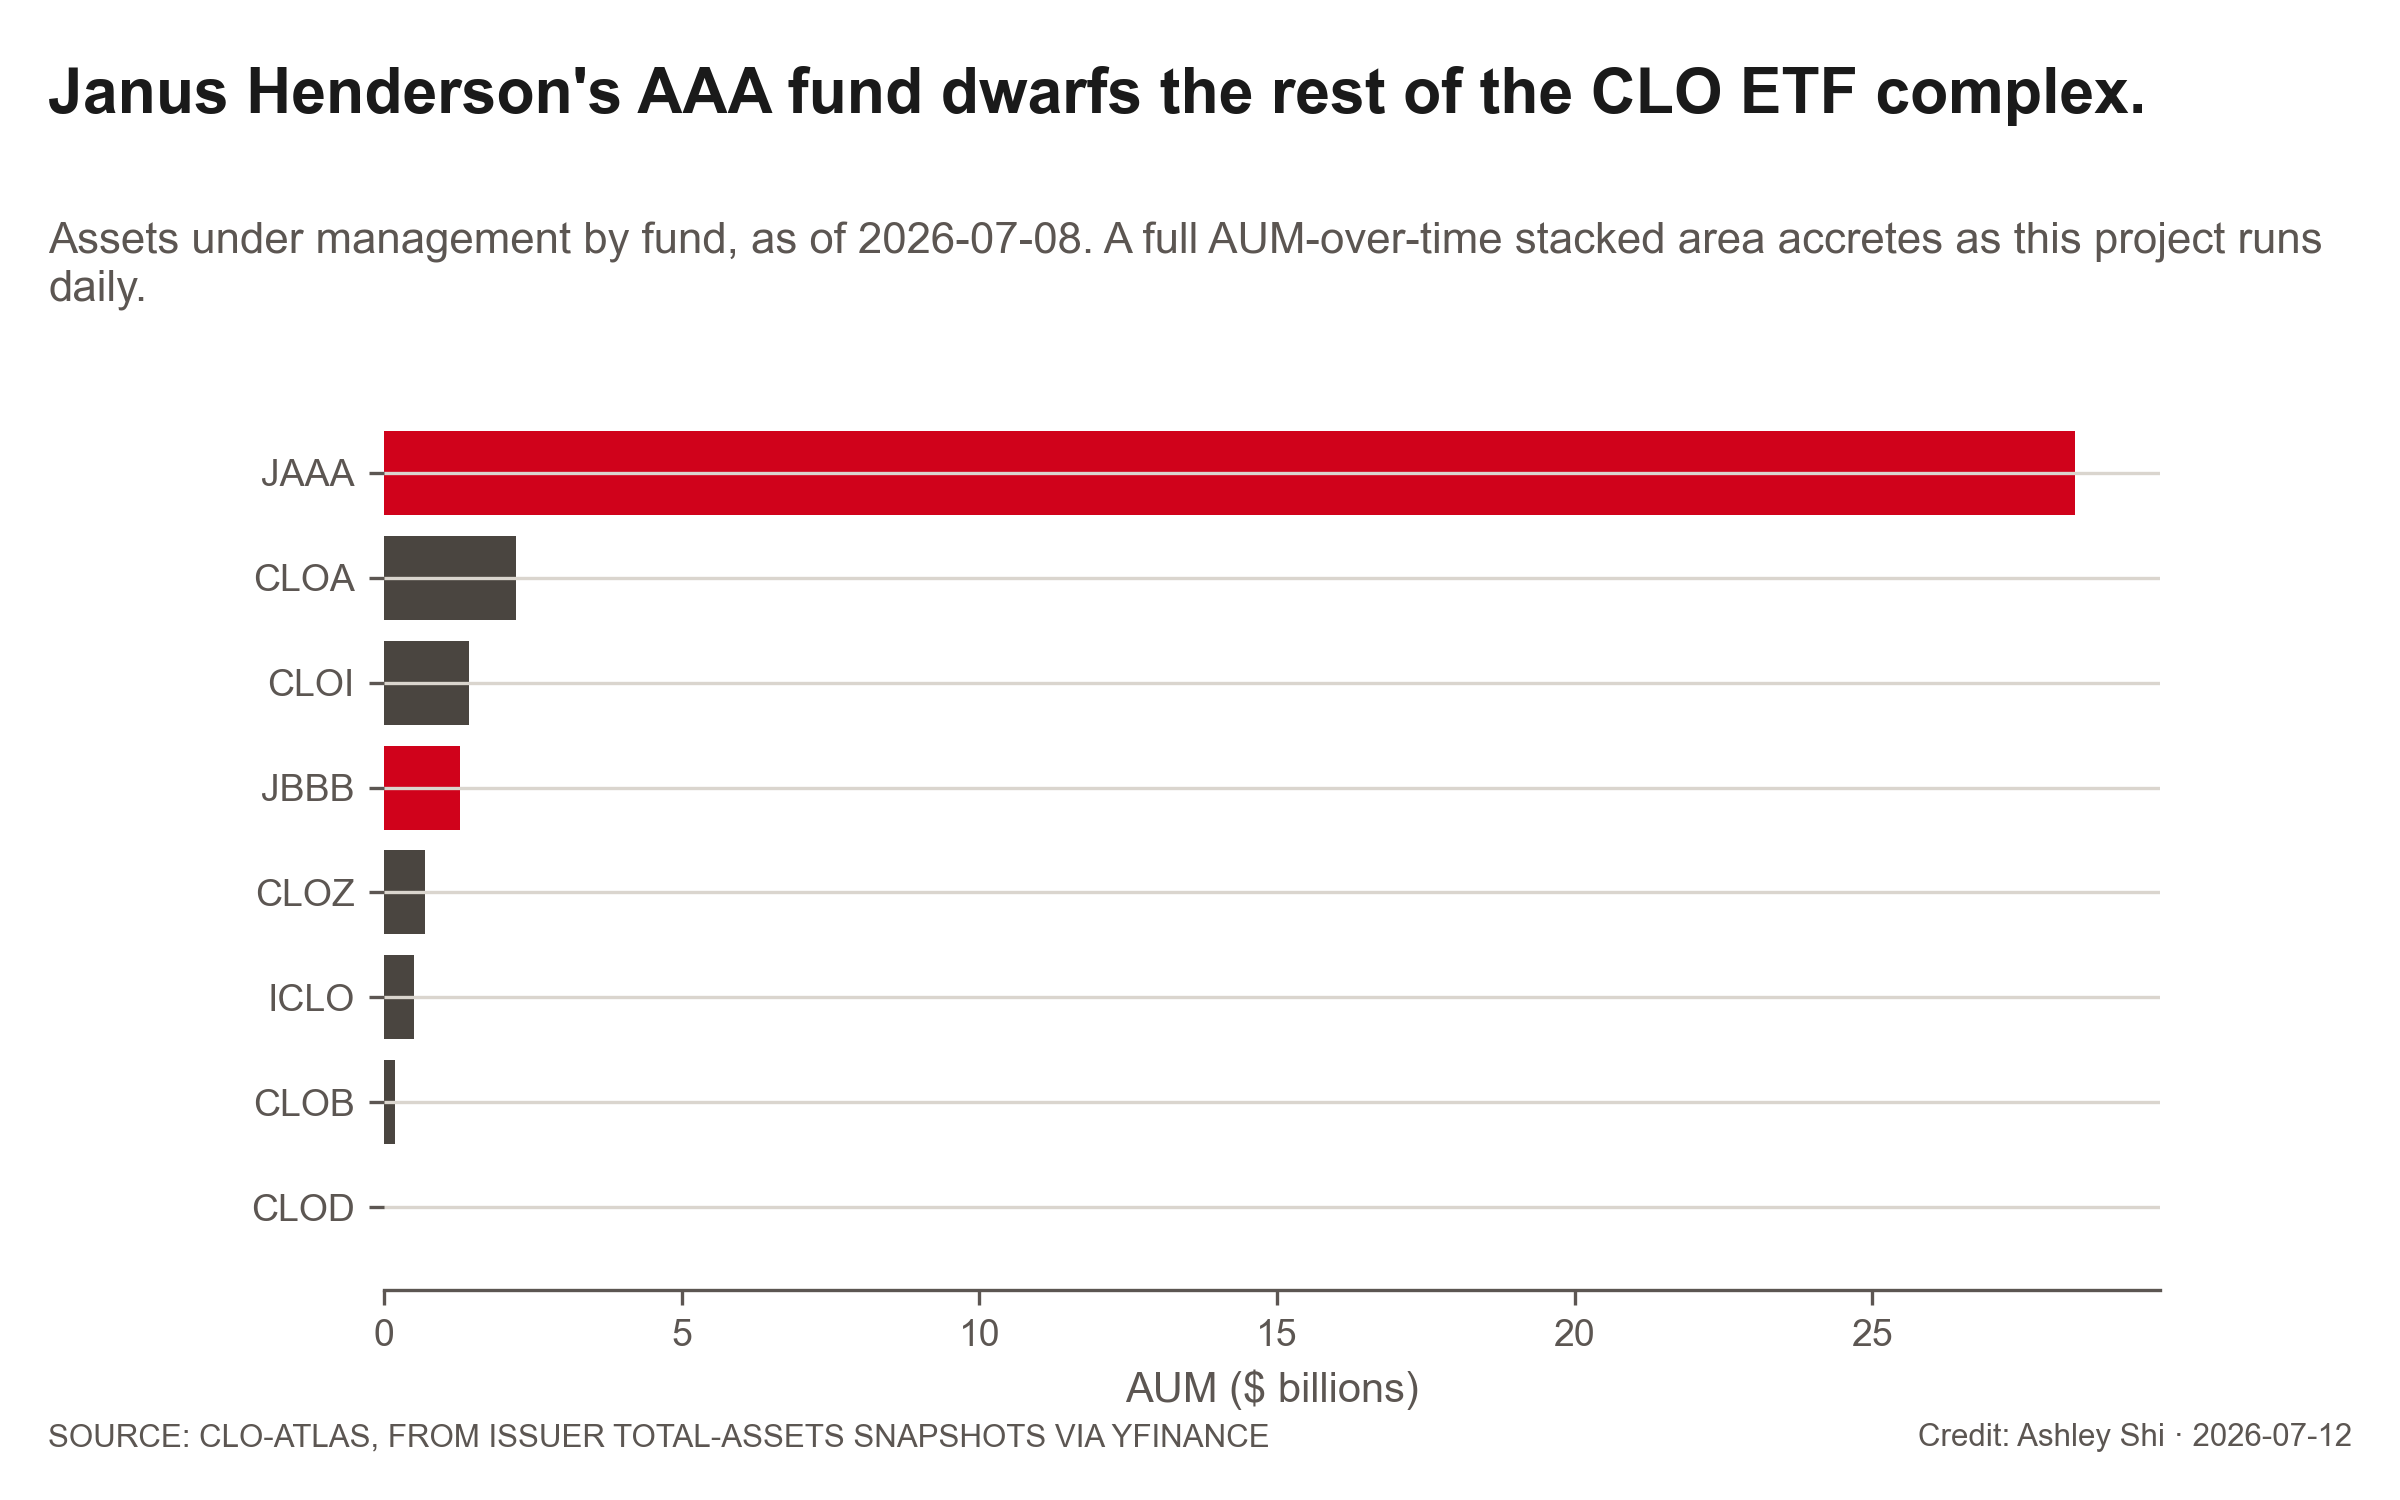

In [8]:
path = pathlib.Path("../figures") / "viz_current_aum.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print("[skipped — not generated this run] viz_current_aum")

**VERIFIED**, computed here: source is each fund's issuer-reported total-assets figure from Yahoo Finance via `yfinance` (`src/etf/scrape_nav_flows.py`), read as a single-date snapshot by `src/etf/analysis_flows.py:aum_by_scrape_date` — no free source publishes historical AUM for these funds, so a true AUM-over-time series can only accrete from here as the project keeps scraping daily. The chart is a horizontal bar of assets under management by fund as of July 8, 2026: JAAA dominates at roughly $28.4 billion, more than ten times any other tracked fund, followed by CLOA ($2.2B), CLOI ($1.4B), JBBB ($1.3B), CLOZ ($0.7B), ICLO ($0.5B), CLOB ($0.18B), and CLOD (under $3M). The concentration matters for the democratization story: retail access to CLOs today functionally means access to one issuer's AAA book, and the long tail of newer entrants — CLOD especially — shows how far the rest of the field still is from real scale.

In [9]:
path = pathlib.Path("../figures") / "viz_monthly_flows.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print("[skipped — not generated this run] viz_monthly_flows")

[skipped — not generated this run] viz_monthly_flows


This exhibit is intentionally empty this run, not a bug: `src/etf/analysis_flows.py`'s `flows_monthly` computes Δ(shares outstanding × NAV) between consecutive NAV-snapshot dates from `scrape_nav_flows.py`, and only a single snapshot date (2026-07-08) has been scraped so far, so the output table is empty by construction until a second date exists (see that module's docstring). **TO-VERIFY** once populated: whether CLO ETF inflows arrive in bursts around specific events (rate decisions, spread widenings) or as a steady drip — that pattern would speak directly to how "sticky" retail/advisor demand for CLO exposure actually is, but it isn't a claim this repo can support yet.

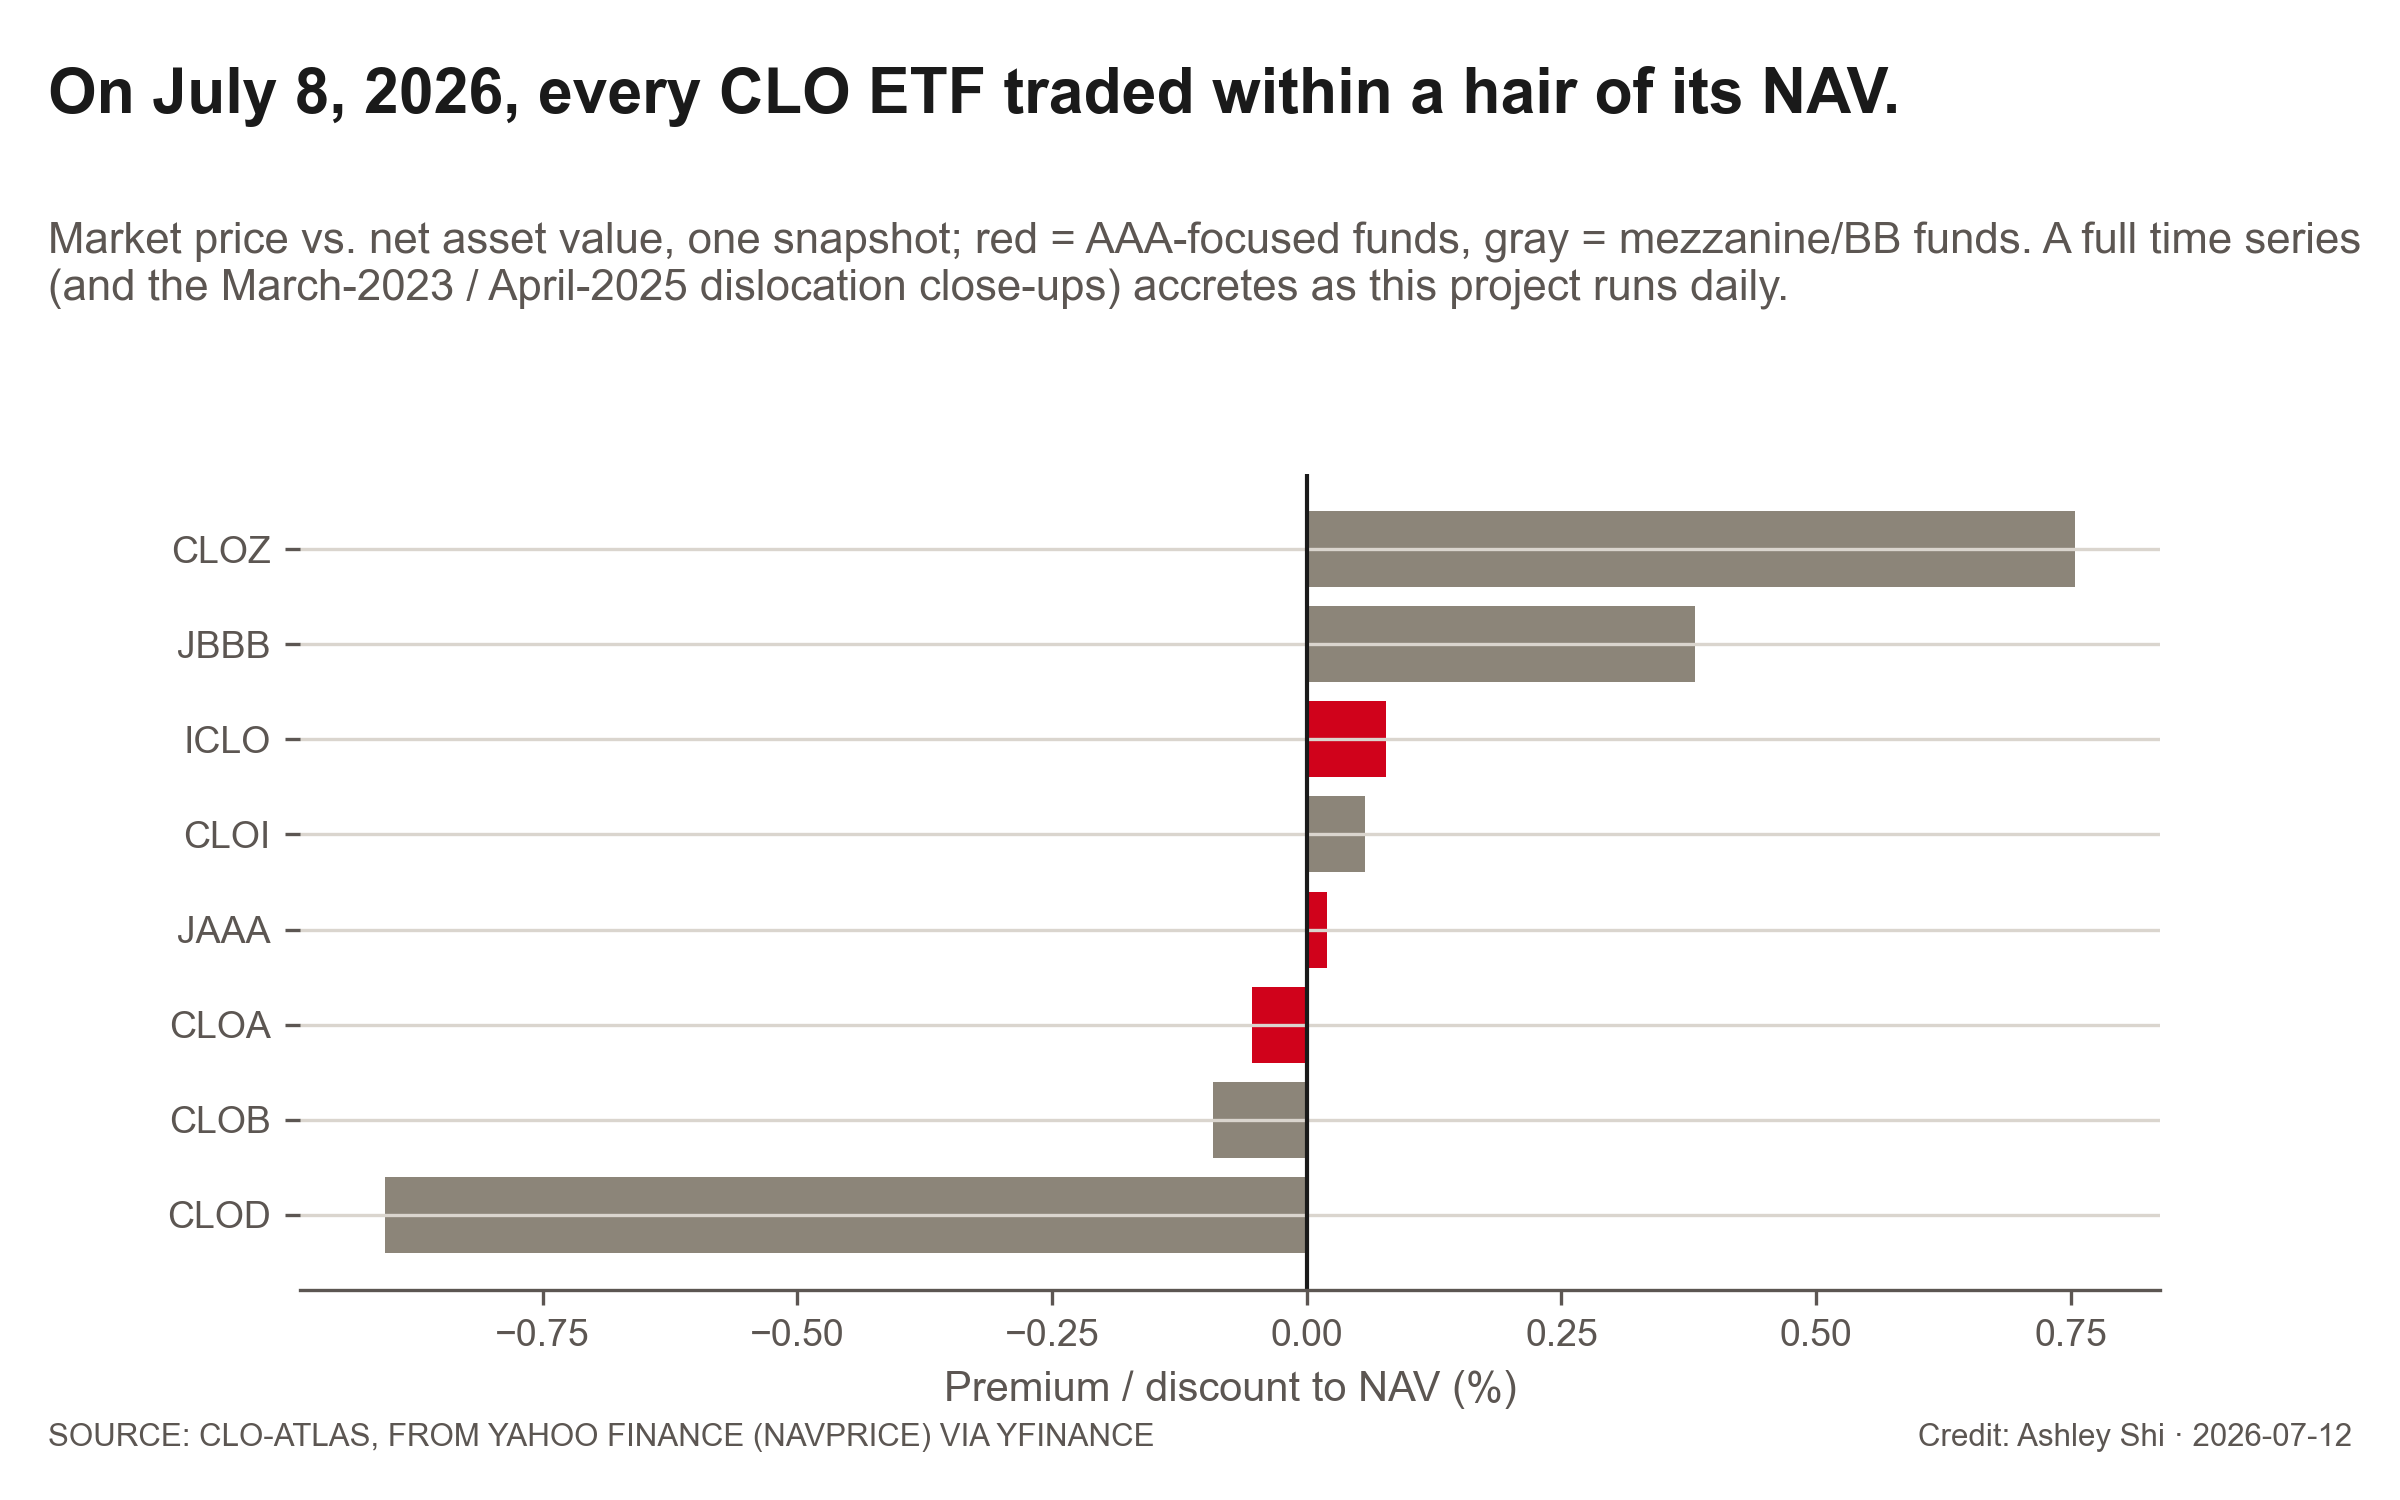

In [10]:
path = pathlib.Path("../figures") / "viz_current_premium_discount.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print("[skipped — not generated this run] viz_current_premium_discount")

**VERIFIED**, computed here: market price and `navPrice` both come from Yahoo Finance via `yfinance` (`src/etf/scrape_nav_flows.py`), differenced into a single-date premium/discount read by `src/etf/viz_dislocation.py:viz_current_premium_discount` — a full multi-year series (including the March 2023 and April 2025 dislocation episodes) needs daily NAV history that only accretes from ongoing scraping. The chart shows all 8 tracked tickers' premium or discount to NAV on July 8, 2026, color-split between AAA-focused funds (red) and mezzanine/BB funds (gray): every fund traded within about 1% of its NAV, from CLOD's -0.9% discount to CLOZ's +0.75% premium. A market this tightly arbitraged is itself evidence for the democratization thesis — authorized-participant creation/redemption is working for CLO ETFs the same way it does for any other fixed-income ETF, which is exactly the plumbing that let CLO exposure move from bilateral OTC trades to a ticker anyone can buy at a fair price intraday.

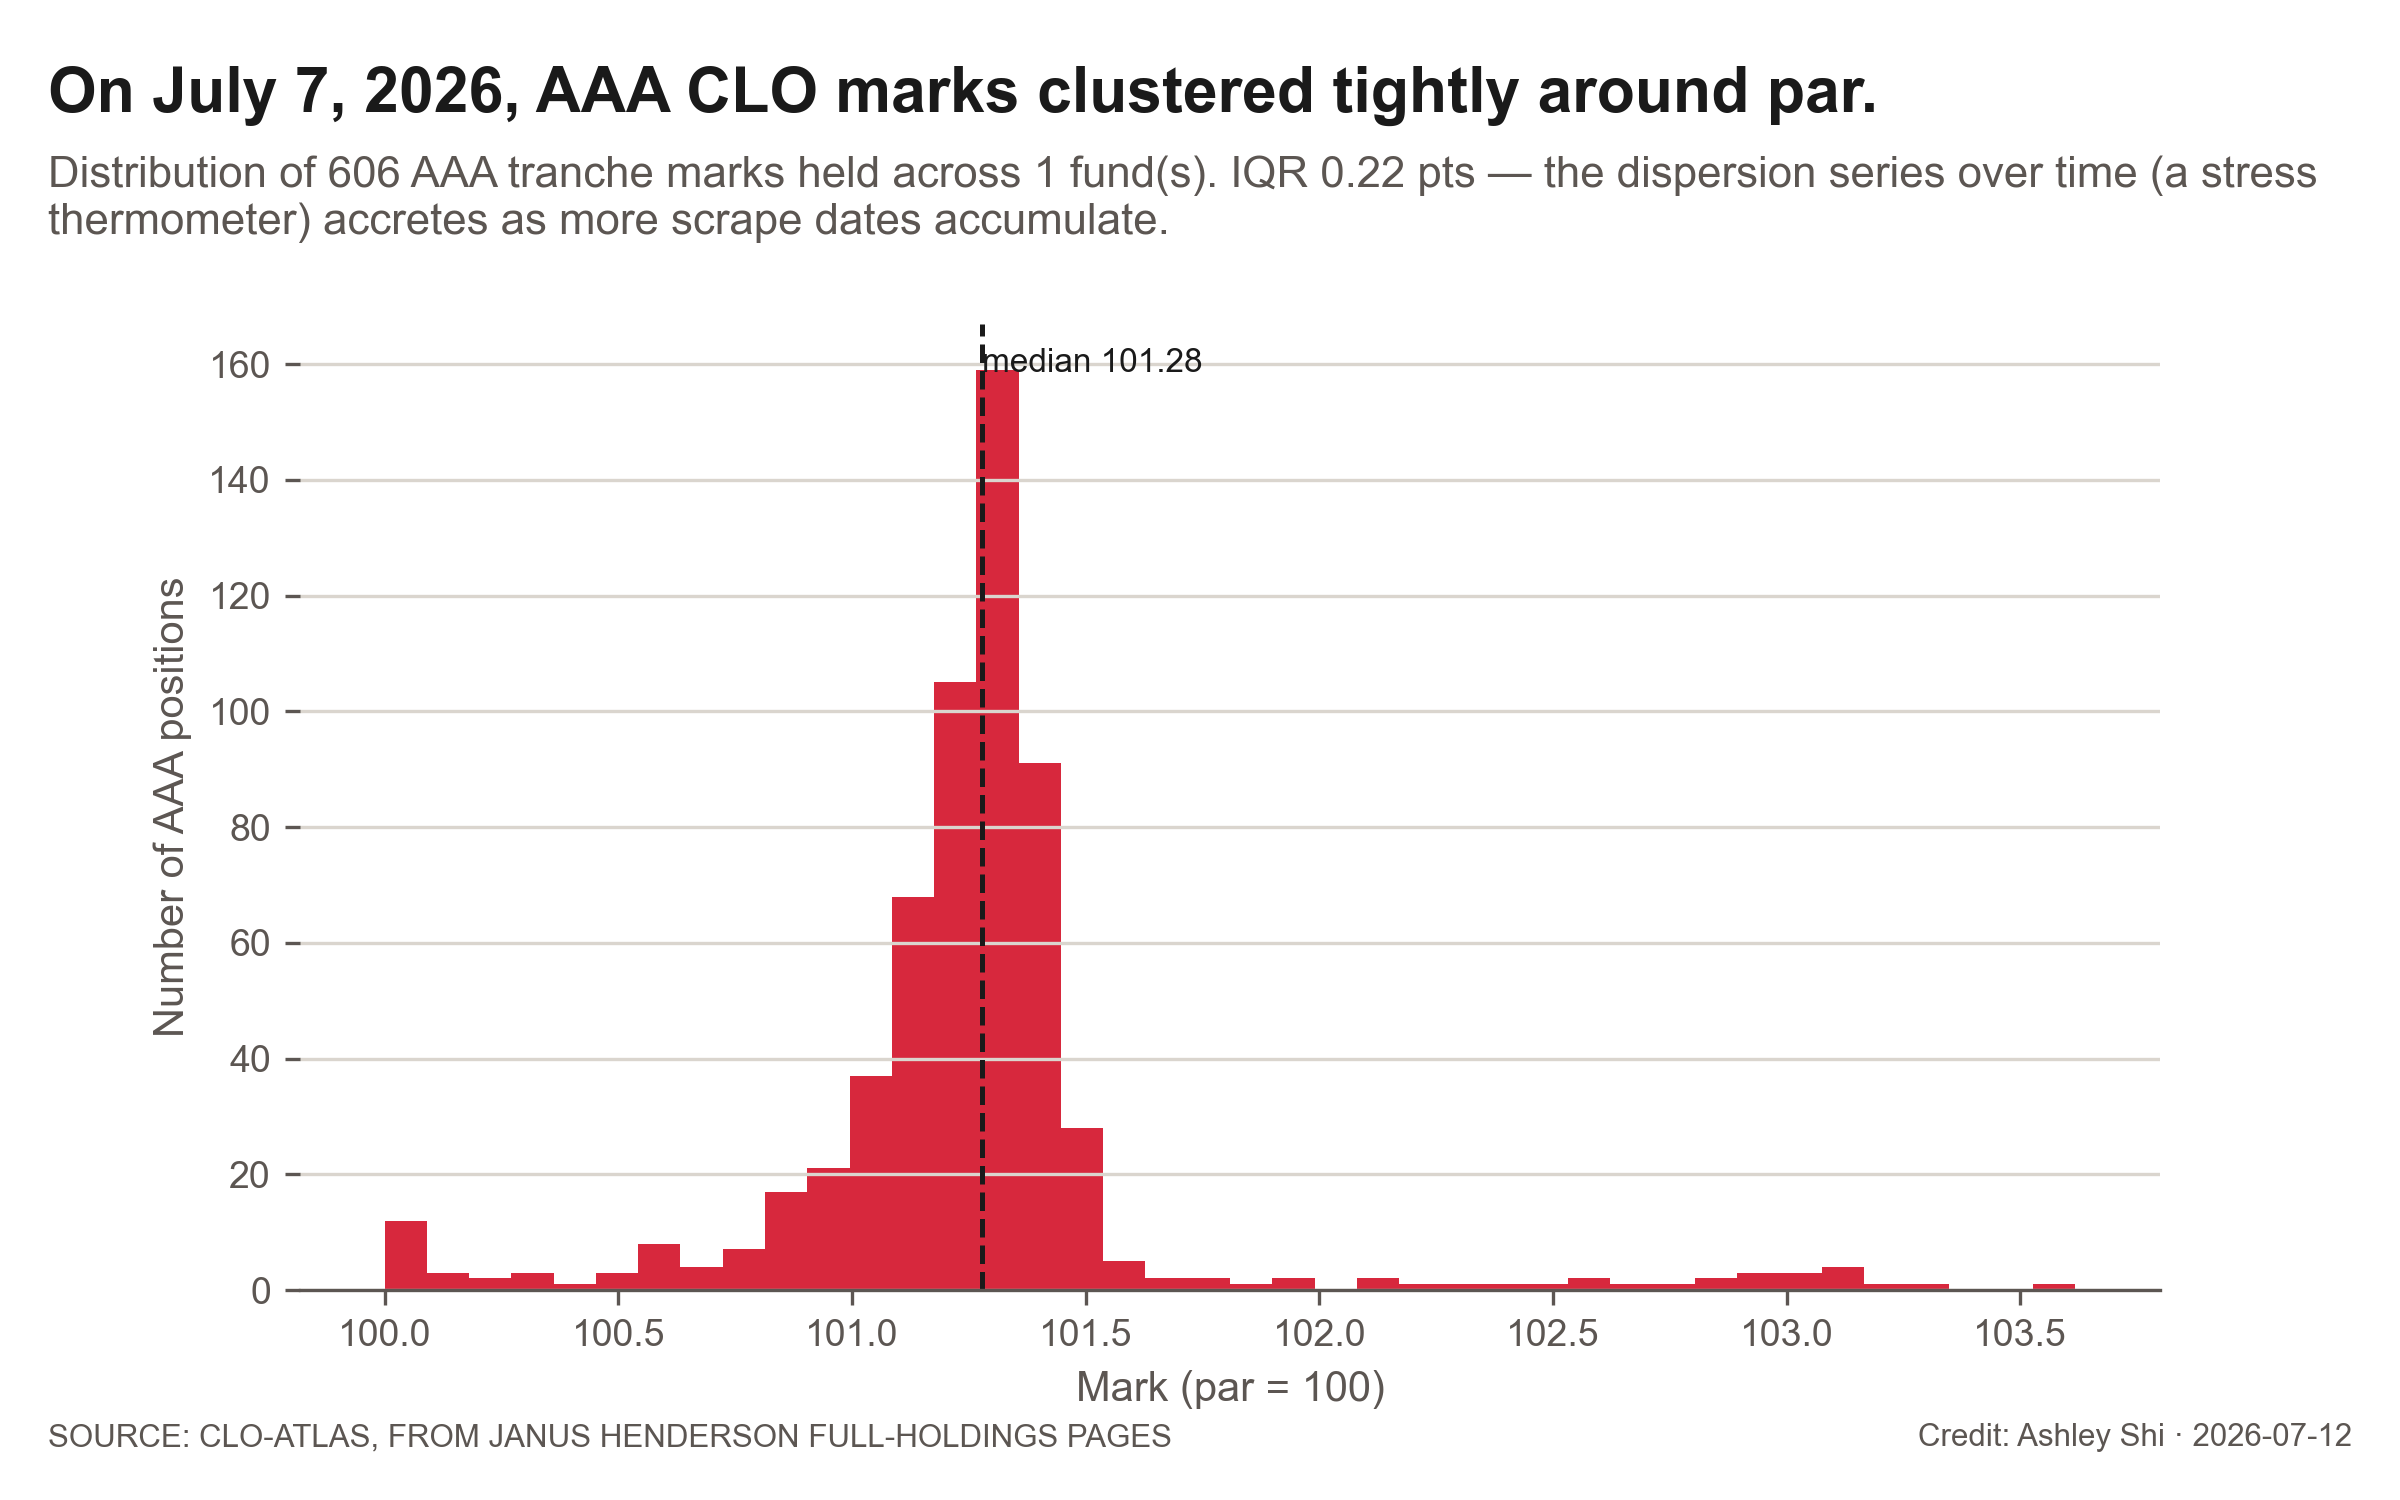

In [11]:
path = pathlib.Path("../figures") / "viz_aaa_mark_distribution.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print("[skipped — not generated this run] viz_aaa_mark_distribution")

**VERIFIED**, computed here: tranche-level marks are scraped from Janus Henderson's server-rendered full-holdings pages for JAAA/JBBB (`src/etf/scrape_holdings.py`, docs/sources.md, verified 2026-07-08), filtered to AAA-focused funds and read into a cross-sectional histogram by `src/etf/viz_tranche.py:viz_aaa_mark_distribution`. As of July 7, 2026 it plots the distribution of every individual AAA CUSIP's price (par = 100) held in the fund, with a median mark of about 101.3 and an interquartile range of roughly 0.22 points — a tight cluster, not a wide spread. This is the "stress thermometer" reading the module is designed to track over time: a tight distribution like this one signals an orderly market where AAA CLO paper trades close to par across issuers, which is the baseline condition retail investors are implicitly relying on when they buy this ETF instead of the underlying tranches directly.

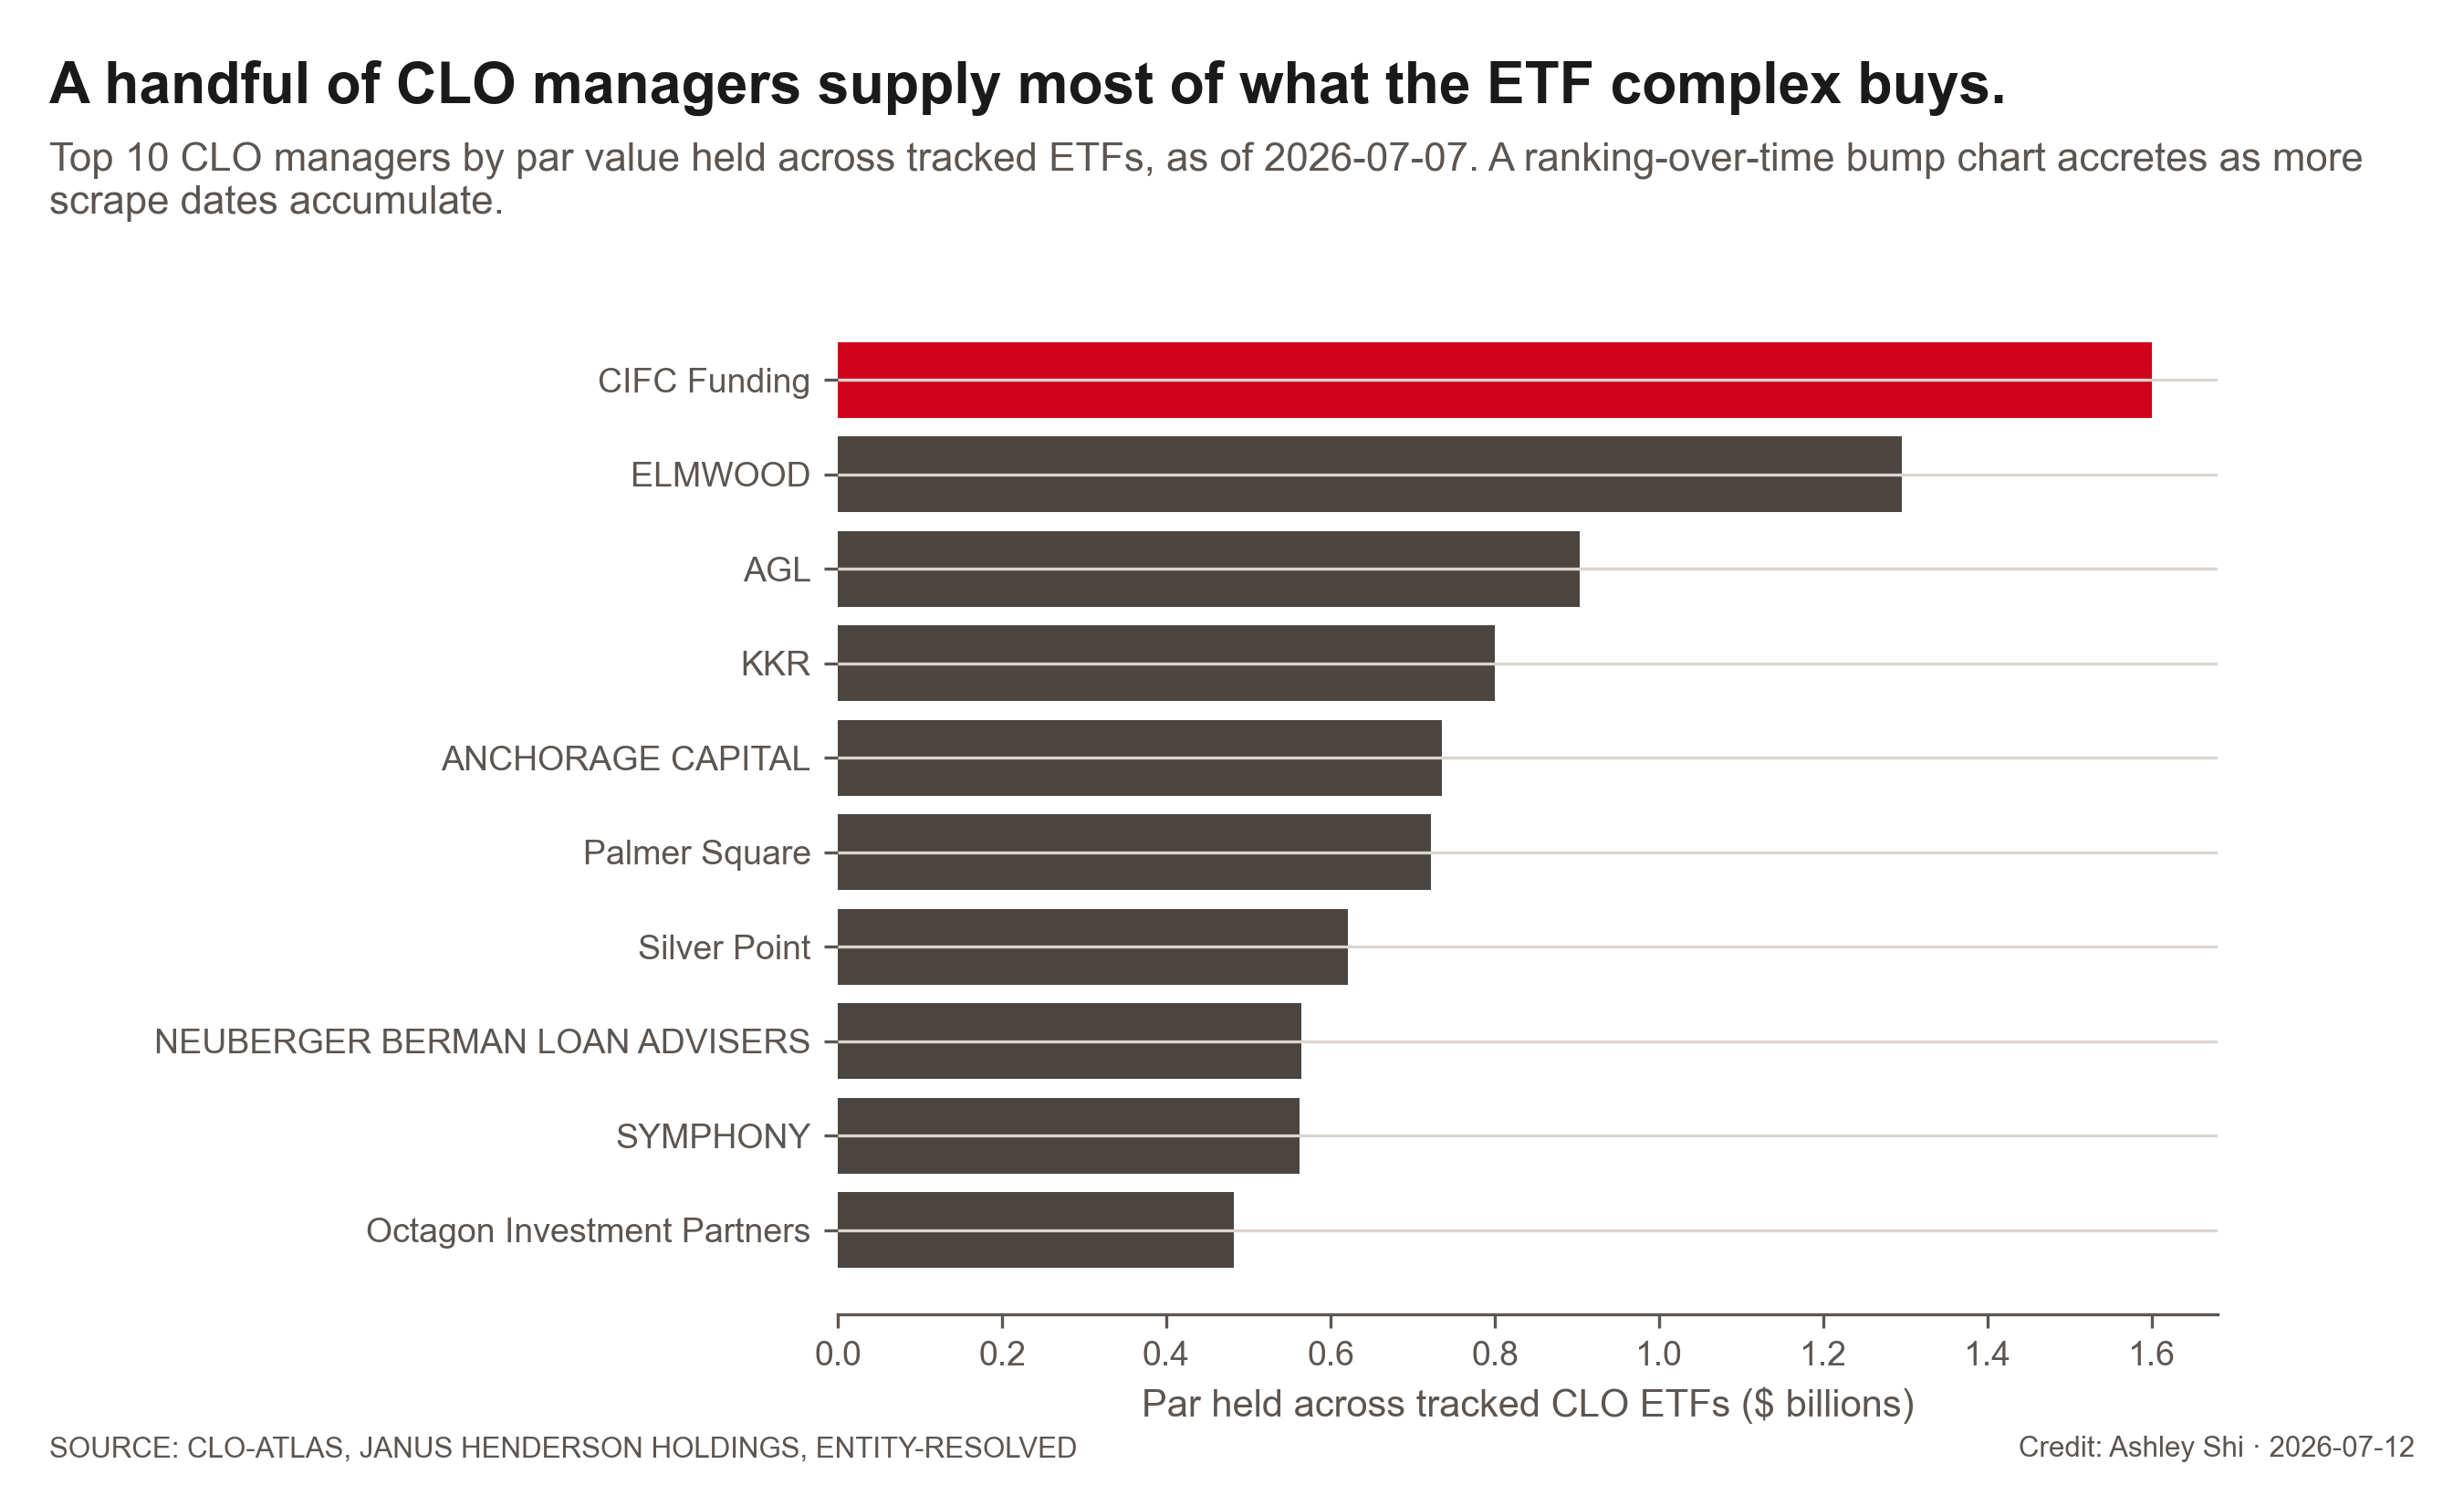

In [12]:
path = pathlib.Path("../figures") / "viz_top10_managers.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print("[skipped — not generated this run] viz_top10_managers")

**VERIFIED**, computed here: same Janus Henderson full-holdings source as the mark-distribution chart (`src/etf/scrape_holdings.py`), aggregated by entity-resolved manager (`src/common/entity.py`'s normalize -> exact -> alias -> fuzzy-match cascade) into total par held across JAAA and JBBB by `src/etf/analysis_manager_league.py`, then ranked by `src/etf/viz_league.py:viz_top10_managers`. The bars show the top 10 CLO managers by par value held across the two funds as of July 7, 2026: CIFC Funding leads at roughly $1.6B, followed by Elmwood (~$1.3B), AGL (~$0.9B), KKR (~$0.8B), and six more ranging from Anchorage Capital (~$0.74B) down to Octagon Investment Partners (~$0.48B). Because JAAA/JBBB are currently the only funds with a scrapable holdings page (the other six issuers' sites are gated — see `docs/excluded_sources.md`), this ranking is really "who Janus Henderson's CLO ETFs buy from," not the whole market; it's still informative for the democratization framing because it shows the retail-facing product concentrating exposure in a recognizable set of institutional managers rather than a diffuse long tail.